# Final Wildfire-Risk Indicator

In this notebook, the two axis of the wildfire-risk indicator are beeing combined (ecological value & vulnerability)! 

**Workflow:**
* First, load both raster for the two axis
* check the CRS, fix it if needed
* align the rasters, so that the cells align perfectly
* make sure, both have the same extent and are masked to the forest area


In [2]:
from pathlib import Path
from io import BytesIO
import sys
import base64
import numpy as np
import pandas as pd
import geopandas as gpd
import numba
import mapclassify
import rasterio
import rasterio.io
from affine import Affine
from rasterio.crs import CRS
from rasterio.enums import Resampling
from rasterio.transform import from_origin, array_bounds
from rasterio.warp import calculate_default_transform, reproject, transform_bounds
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from PIL import Image
import folium
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from branca.colormap import LinearColormap
from branca.element import MacroElement
from IPython.display import display

ROOT_DIR = Path.cwd()

if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

# 2. Define Folder Paths 
PATH_DATA = ROOT_DIR / 'Data'
PATH_RAW = PATH_DATA / 'Raw'
PATH_PROCESSED = PATH_DATA / 'Processed'
PATH_OUTPUTS = ROOT_DIR / 'Outputs'

TARGET_CRS = CRS.from_epsg(3035)
RESOLUTION = 1000
NODATA = -9999.0

mesli_path = PATH_OUTPUTS / 'MESLI_ecological_value_1000m_epsg3035.tif'
vulnerability_path = PATH_RAW / 'final_vulnerability_layer.tif'
forest_mask = PATH_PROCESSED / 'forest_mask_1000m_epsg3035.tif'

input_paths = [mesli_path, vulnerability_path, forest_mask]
pd.DataFrame({'file': [str(p) for p in input_paths], 'exists': [p.exists() for p in input_paths]})

,file,exists
0,/Users/maxlengenfelder/Desktop/FS26/GEO888/GEO...,True
1,/Users/maxlengenfelder/Desktop/FS26/GEO888/GEO...,True
2,/Users/maxlengenfelder/Desktop/FS26/GEO888/GEO...,True


## 1. Input raster preparation

In [3]:
with rasterio.open(forest_mask) as src:
    left, bottom, right, top = transform_bounds(src.crs, TARGET_CRS, *src.bounds, densify_pts=21)

left = np.floor(left / RESOLUTION) * RESOLUTION
bottom = np.floor(bottom / RESOLUTION) * RESOLUTION
right = np.ceil(right / RESOLUTION) * RESOLUTION
top = np.ceil(top / RESOLUTION) * RESOLUTION

width = int((right - left) / RESOLUTION)
height = int((top - bottom) / RESOLUTION)
transform = from_origin(left, top, RESOLUTION, RESOLUTION)

profile = {
    'driver': 'GTiff',
    'height': height,
    'width': width,
    'count': 1,
    'dtype': 'float32',
    'crs': TARGET_CRS,
    'transform': transform,
    'nodata': NODATA,
    'compress': 'lzw',
    'tiled': True,
    'blockxsize': 256,
    'blockysize': 256,
    'BIGTIFF': 'IF_SAFER',
}

print(f'Template: EPSG:3035, {RESOLUTION} m, {width} x {height} pixels')

Template: EPSG:3035, 1000 m, 6500 x 4600 pixels


## 2. Load rasters — skip reprojection if already aligned

A small helper checks CRS, shape and transform against the target profile. If a raster already matches, it is read directly — no unnecessary reprojection.

In [4]:
def needs_reproject(path, profile):
    """
    True if the raster at path does not already match the target profile.
    """
    with rasterio.open(path) as src:
        same_crs    = CRS.from_user_input(src.crs) == CRS.from_user_input(profile['crs'])
        same_shape  = (src.height == profile['height']) and (src.width == profile['width'])
        same_transform = np.allclose(
            [src.transform.a, src.transform.e, src.transform.c, src.transform.f],
            [profile['transform'].a, profile['transform'].e,
             profile['transform'].c, profile['transform'].f],
            atol=1e-3
        )
    return not (same_crs and same_shape and same_transform)


def load_aligned(path, profile, resampling=Resampling.bilinear):
    """
    Load a raster aligned to profile — reproject only if needed.
    """
    arr = np.full((profile['height'], profile['width']), np.nan, dtype='float32')
    with rasterio.open(path) as src:
        if needs_reproject(path, profile):
            print(f'  → reprojecting {path.name}  ({src.crs}, {src.res[0]:.0f} m)')
            reproject(
                source=rasterio.band(src, 1),
                destination=arr,
                src_transform=src.transform,
                src_crs=src.crs,
                src_nodata=src.nodata,
                dst_transform=profile['transform'],
                dst_crs=profile['crs'],
                dst_nodata=np.nan,
                resampling=resampling,
            )
        else:
            print(f'  → already aligned, reading directly: {path.name}')
            arr = src.read(1).astype('float32')
            arr[arr == src.nodata] = np.nan
    return arr

forest_mask_arr = load_aligned(forest_mask, profile, resampling=Resampling.nearest)
    
print('Loading MESLI:')
mesli_arr = load_aligned(mesli_path, profile)

print('Loading Vulnerability:')
vuln_raw = load_aligned(vulnerability_path, profile)

v_min, v_max = np.nanmin(vuln_raw), np.nanmax(vuln_raw)
vuln_norm = np.full_like(vuln_raw, np.nan)
valid_vuln = np.isfinite(vuln_raw)
vuln_norm[valid_vuln] = (vuln_raw[valid_vuln] - v_min) / (v_max - v_min)

valid_intersection = np.isfinite(mesli_arr) & np.isfinite(vuln_norm) & (forest_mask_arr == 1)

mesli_arr[~valid_intersection] = np.nan
vuln_norm[~valid_intersection] = np.nan

print(f'\nMESLI        valid: {int(np.isfinite(mesli_arr).sum()):>9,}  range: {np.nanmin(mesli_arr):.3f} – {np.nanmax(mesli_arr):.3f}')
print(f'Vuln (norm)  valid: {int(np.isfinite(vuln_norm).sum()):>9,}  range: {np.nanmin(vuln_norm):.3f} – {np.nanmax(vuln_norm):.3f}')
print(f'Gemeinsamer Wald:  {int(valid_intersection.sum()):>9,}')

  → already aligned, reading directly: forest_mask_1000m_epsg3035.tif
Loading MESLI:
  → already aligned, reading directly: MESLI_ecological_value_1000m_epsg3035.tif
Loading Vulnerability:
  → reprojecting final_vulnerability_layer.tif  (EPSG:4326, 0 m)

MESLI        valid: 1,160,138  range: 0.000 – 1.000
Vuln (norm)  valid: 1,160,138  range: 0.000 – 0.995
Gemeinsamer Wald:  1,160,138


## 3. Bivariate 2×2 classification

Each forest pixel is assigned to one of four quadrants based on whether its MESLI and Vulnerability values are above or below the fisherjenks threshold.

| Class | EV | V | Priority |
|---|---|---|---|
| 1 | Low  | Low  | Low |
| 2 | Low  | High | Medium |
| 3 | High | Low  | Medium |
| 4 | **High** | **High** | **Critical** |


In [5]:
def fisher_breaks(arr, k=2):
    """
    Fisher-Jenks breaks für ein 2D-Array, ignoriert NaN.
    """
    valid = arr[np.isfinite(arr)].ravel()
    if len(valid) > 50_000:
        valid = np.random.choice(valid, 50_000, replace=False)
    return mapclassify.FisherJenks(valid, k=k).bins

# 1. Fisher-Jenks-Splits ermitteln
# Bei k=2 enthält 'breaks' zwei Werte: [Trennschwelle, Maximum]
breaks_ev = fisher_breaks(mesli_arr, k=2)
breaks_v  = fisher_breaks(vuln_norm,  k=2)

# Die eigentliche Trennschwelle ist jeweils das erste Element
thresh_ev = breaks_ev[0]
thresh_v  = breaks_v[0]

print(f"Treshold MESLI:         {thresh_ev:.4f}")
print(f"Treshold Vulnerability: {thresh_v:.4f}")

# 2. Klassifizieren (Ergibt 0 für 'Low' und 1 für 'High')
# Durch den '>=' Vergleich werden auch die Maximalwerte (1.0) absolut sicher der Klasse 1 zugeordnet!
ev_class = np.where(mesli_arr >= thresh_ev, 1, 0)
v_class  = np.where(vuln_norm >= thresh_v, 1, 0)

# 3. Kombination zu den Klassen 1, 2, 3, 4
bivariate = (ev_class * 2 + v_class + 1).astype('float32')

# 4. Die NaN-Maske wieder präzise aufprägen (Schnittmenge aus Zelle 5 absichern)
bivariate[np.isnan(mesli_arr) | np.isnan(vuln_norm)] = np.nan

# Kontroll-Check
unique_classes = np.unique(bivariate[np.isfinite(bivariate)])
print(f"Generated bivariate classes: {unique_classes} (Expected: [1. 2. 3. 4.])")

Treshold MESLI:         0.4326
Treshold Vulnerability: 0.5132
Generated bivariate classes: [1. 2. 3. 4.] (Expected: [1. 2. 3. 4.])


## 4. Static overview plot

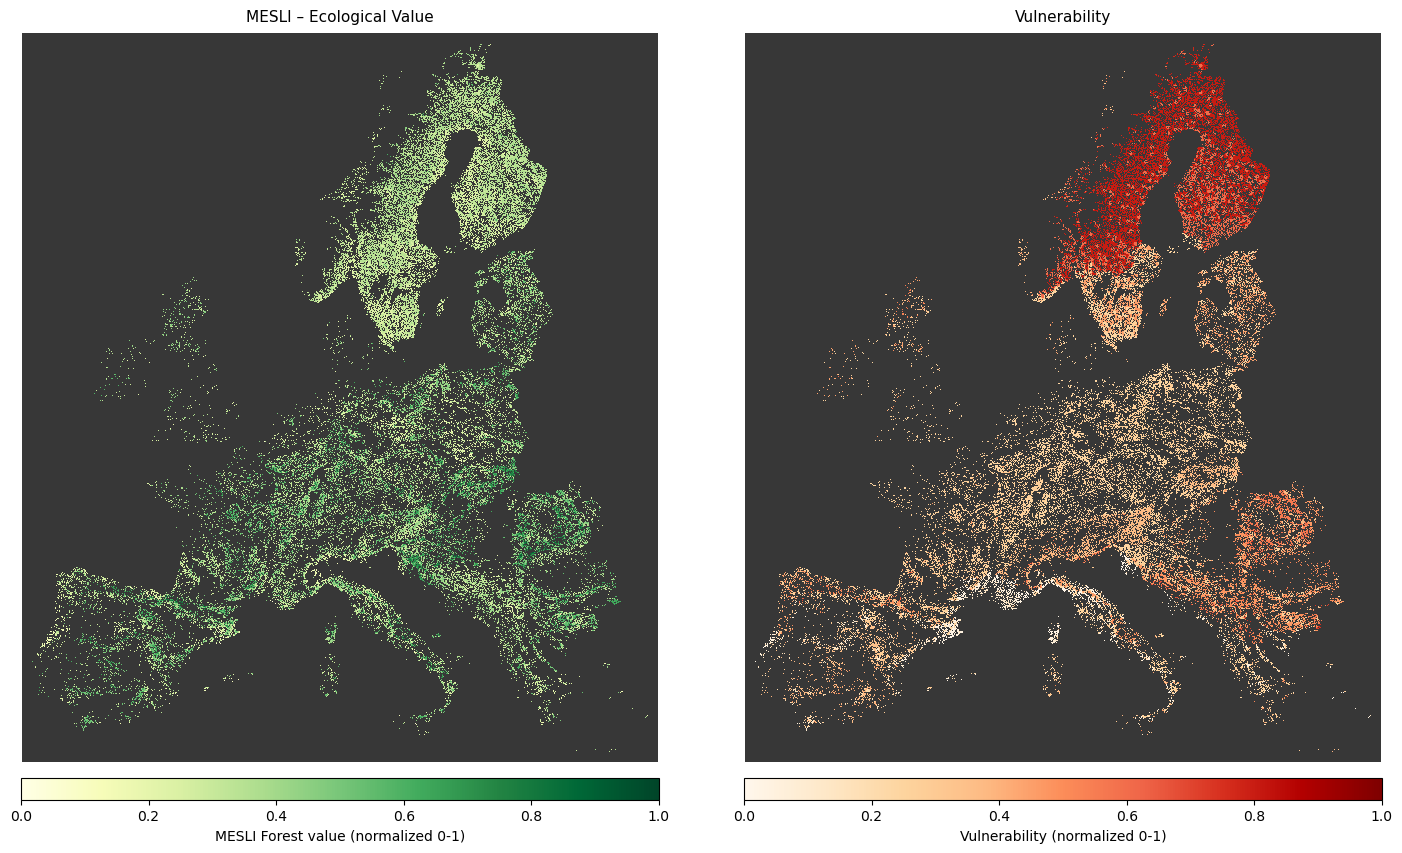

In [6]:
BG    = "#FFFFFF"
SCALE = 1.2

# Matplotlib global für den Darkmode konfigurieren
plt.rcParams.update({
    'figure.facecolor': BG, 
    'axes.facecolor': BG,
    'text.color': 'black', 
    'axes.labelcolor': 'black'
})

# Colormaps kopieren und NaN-Farbe (Hintergrund-Füllung) definieren
mesli_cmap = plt.colormaps["YlGn"].copy()
mesli_cmap.set_bad(color="#373737FF")

vuln_cmap = plt.colormaps["OrRd"].copy()
vuln_cmap.set_bad(color="#373737FF")

# --- MULTI-PANEL SETUP ---
fig, axes = plt.subplots(1, 2, figsize=(12 * SCALE, 7 * SCALE), layout="constrained")
fig.patch.set_facecolor(BG)

# Panel 1: MESLI – Ecological Value
axes[0].set_facecolor(BG)
im0 = axes[0].imshow(mesli_arr, cmap=mesli_cmap, vmin=0, vmax=1, interpolation='nearest')
cb0 = fig.colorbar(im0, ax=axes[0], orientation='horizontal', label='MESLI Forest value (normalized 0-1)', shrink=0.9, aspect=30, pad=0.02)
cb0.ax.tick_params(colors='black')
axes[0].set_title('MESLI – Ecological Value', color='black', fontsize=11, pad=8)

# Panel 2: Vulnerability
axes[1].set_facecolor(BG)
im1 = axes[1].imshow(vuln_norm, cmap=vuln_cmap, vmin=0, vmax=1, interpolation='nearest')
cb1 = fig.colorbar(im1, ax=axes[1], orientation='horizontal', label='Vulnerability (normalized 0-1)', shrink=0.9, aspect=30, pad=0.02)
cb1.ax.tick_params(colors='black')
axes[1].set_title('Vulnerability', color='black', fontsize=11, pad=8)


# --- SYNCHRONER AUTO-ZOOM ZU DEN VALIDEN DATEN ---
# Da beide Raster deckungsgleich sind, nutzen wir mesli_arr für die Grenzwertberechnung
valid_pixels = np.argwhere(~np.isnan(mesli_arr))

if len(valid_pixels) > 0:
    # Mindest- und Maximalwerte der Zeilen (y) und Spalten (x) ermitteln
    ymin, xmin = valid_pixels.min(axis=0)
    ymax, xmax = valid_pixels.max(axis=0)
    # Kompakter Puffer (Pixel), damit die Karte optimal den Platz ausfüllt
    buffer = 50 
    # Sicherheits-Begrenzung (Clamping) innerhalb der Array-Dimensionen
    xmin_lim = max(0, xmin - buffer)
    xmax_lim = min(mesli_arr.shape[1], xmax + buffer)
    ymin_lim = min(mesli_arr.shape[0], ymax + buffer)
    ymax_lim = max(0, ymin - buffer)
    # Limits auf BEIDE Achsen identisch anwenden & Achsenbeschriftung ausschalten
    for ax in axes:
        ax.set_xlim(xmin_lim, xmax_lim)
        ax.set_ylim(ymin_lim, ymax_lim) # ymin/ymax getauscht, da bei imshow y=0 oben liegt
        ax.axis('off')
else:
    for ax in axes:
        ax.axis('off')

fig.savefig(PATH_OUTPUTS / 'Wildfire_Bivariate_preview.png',
            dpi=300, bbox_inches='tight', facecolor=BG)
plt.show(block=False)

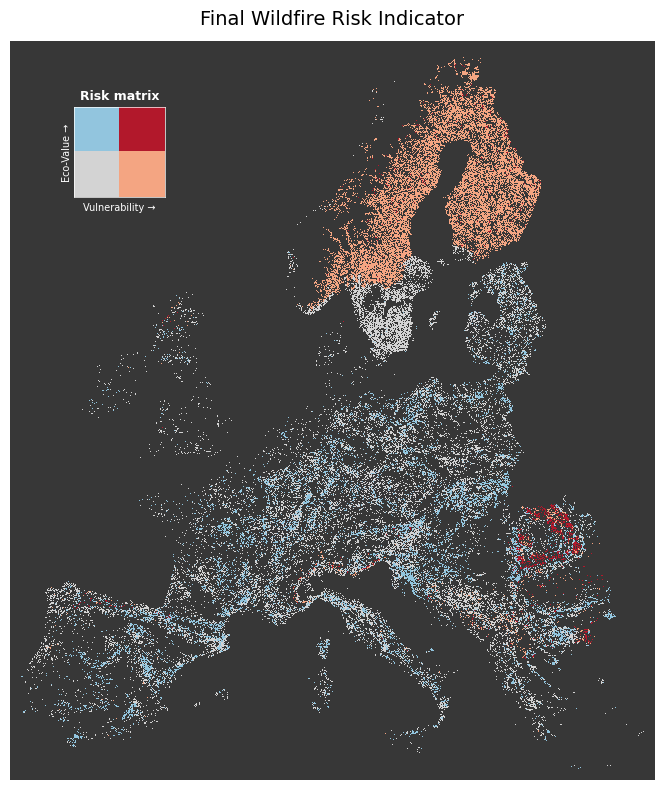

In [75]:
BG    = "#FFFFFF"
SCALE = 1.2
NAN_COLOR = "#373737" 

BIV_COLORS = {
    1: '#d3d3d3',   # Low EV,  Low V  → hellgrau
    2: '#f4a582',   # Low EV,  High V → orange
    3: '#92c5de',   # High EV, Low V  → blau
    4: '#b2182b',   # High EV, High V → rot (kritisch)
}

BIV_LABELS = {
    1: 'Low EV / Low V',
    2: 'Low EV / High V',
    3: 'High EV / Low V',
    4: 'High EV / High V (critical)',
}

plt.rcParams.update({
    'figure.facecolor': BG, 
    'axes.facecolor': BG,
    'text.color': 'black', 
    'axes.labelcolor': 'black'
})

fig, ax = plt.subplots(1, 1, figsize=(12 * SCALE, 8 * SCALE))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# 1. RGB-Array vorbereiten (4 Kanäle für RGBA)
biv_rgb = np.zeros((*bivariate.shape, 4), dtype='uint8')

# 2. Die bivariaten Klassen mit Farben füllen
for cls, hex_col in BIV_COLORS.items():
    biv_rgb[bivariate == cls] = [int(v * 255) for v in mcolors.to_rgba(hex_col)]

# 3. NEU: Alle NaN- / unendlichen Pixel mit dem dunklen Grau füllen
nan_mask = ~np.isfinite(bivariate)
biv_rgb[nan_mask] = [int(v * 255) for v in mcolors.to_rgba(NAN_COLOR)]

# Karte plotten
ax.imshow(biv_rgb, interpolation='nearest')
ax.set_title('Final Wildfire Risk Indicator', color='black', fontsize=14, pad=12)
ax.axis('off')

# --- AUTO-ZOOM ZU DEN VALIDEN DATEN ---
valid_pixels = np.argwhere(np.isfinite(bivariate))

if len(valid_pixels) > 0:
    ymin, xmin = valid_pixels.min(axis=0)
    ymax, xmax = valid_pixels.max(axis=0)

    # Einheitlicher Puffer (z.B. 60 Pixel)
    buffer = 60 

    # Sicherheits-Begrenzung (Clamping) innerhalb der Array-Dimensionen
    xmin_lim = max(0, xmin - buffer)
    xmax_lim = min(bivariate.shape[1], xmax + buffer)
    ymin_lim = min(bivariate.shape[0], ymax + buffer)
    ymax_lim = max(0, ymin - buffer)
    
    ax.set_xlim(xmin_lim, xmax_lim)
    ax.set_ylim(ymin_lim, ymax_lim) 

ax_leg = inset_axes(
    ax, 
    width='14%', 
    height='14%', 
    loc='upper left', 
    bbox_to_anchor=(0.1, -0.08, 1, 1), 
    bbox_transform=ax.transAxes,
    borderpad=0
)
ax_leg.set_facecolor(BG)

# 2x2 Matrix für die Legende aufbauen
leg_matrix  = np.array([[3, 4], [1, 2]])   # Obere Reihe = High EV
leg_rgba    = np.zeros((2, 2, 4), dtype='uint8')
for r in range(2):
    for c in range(2):
        leg_rgba[r, c] = [int(v*255) for v in mcolors.to_rgba(BIV_COLORS[int(leg_matrix[r, c])])]

ax_leg.imshow(leg_rgba, origin='upper', interpolation='nearest')
ax_leg.set_title('Risk matrix', color='white', fontsize=9, pad=5, weight='bold')
ax_leg.set_xticks([])
#ax_leg.set_xticklabels(['Low', 'High'], color='white', fontsize=7)
ax_leg.set_yticks([])
#ax_leg.set_yticklabels(['High', 'Low'], color='white', fontsize=7)
ax_leg.set_xlabel('Vulnerability →', color='white', fontsize=7, labelpad=4)
ax_leg.set_ylabel('Eco-Value →', color='white', fontsize=7, labelpad=2)

for sp in ax_leg.spines.values():
    sp.set_edgecolor('white')
    sp.set_linewidth(0.5)

fig.savefig(PATH_OUTPUTS / 'Wildfire_Bivariate_matrix_final.png', dpi=300, bbox_inches='tight', facecolor=BG)
plt.show(block=False)

## 5. Interactive Folium map

The bivariate classes are rendered as a categorical RGBA overlay. MESLI and vulnerability are added as optional toggle layers.

Saved to /Users/maxlengenfelder/Desktop/FS26/GEO888/GEO888_Wildfire_Indicator/Outputs/Wildfire_interactive_map.html



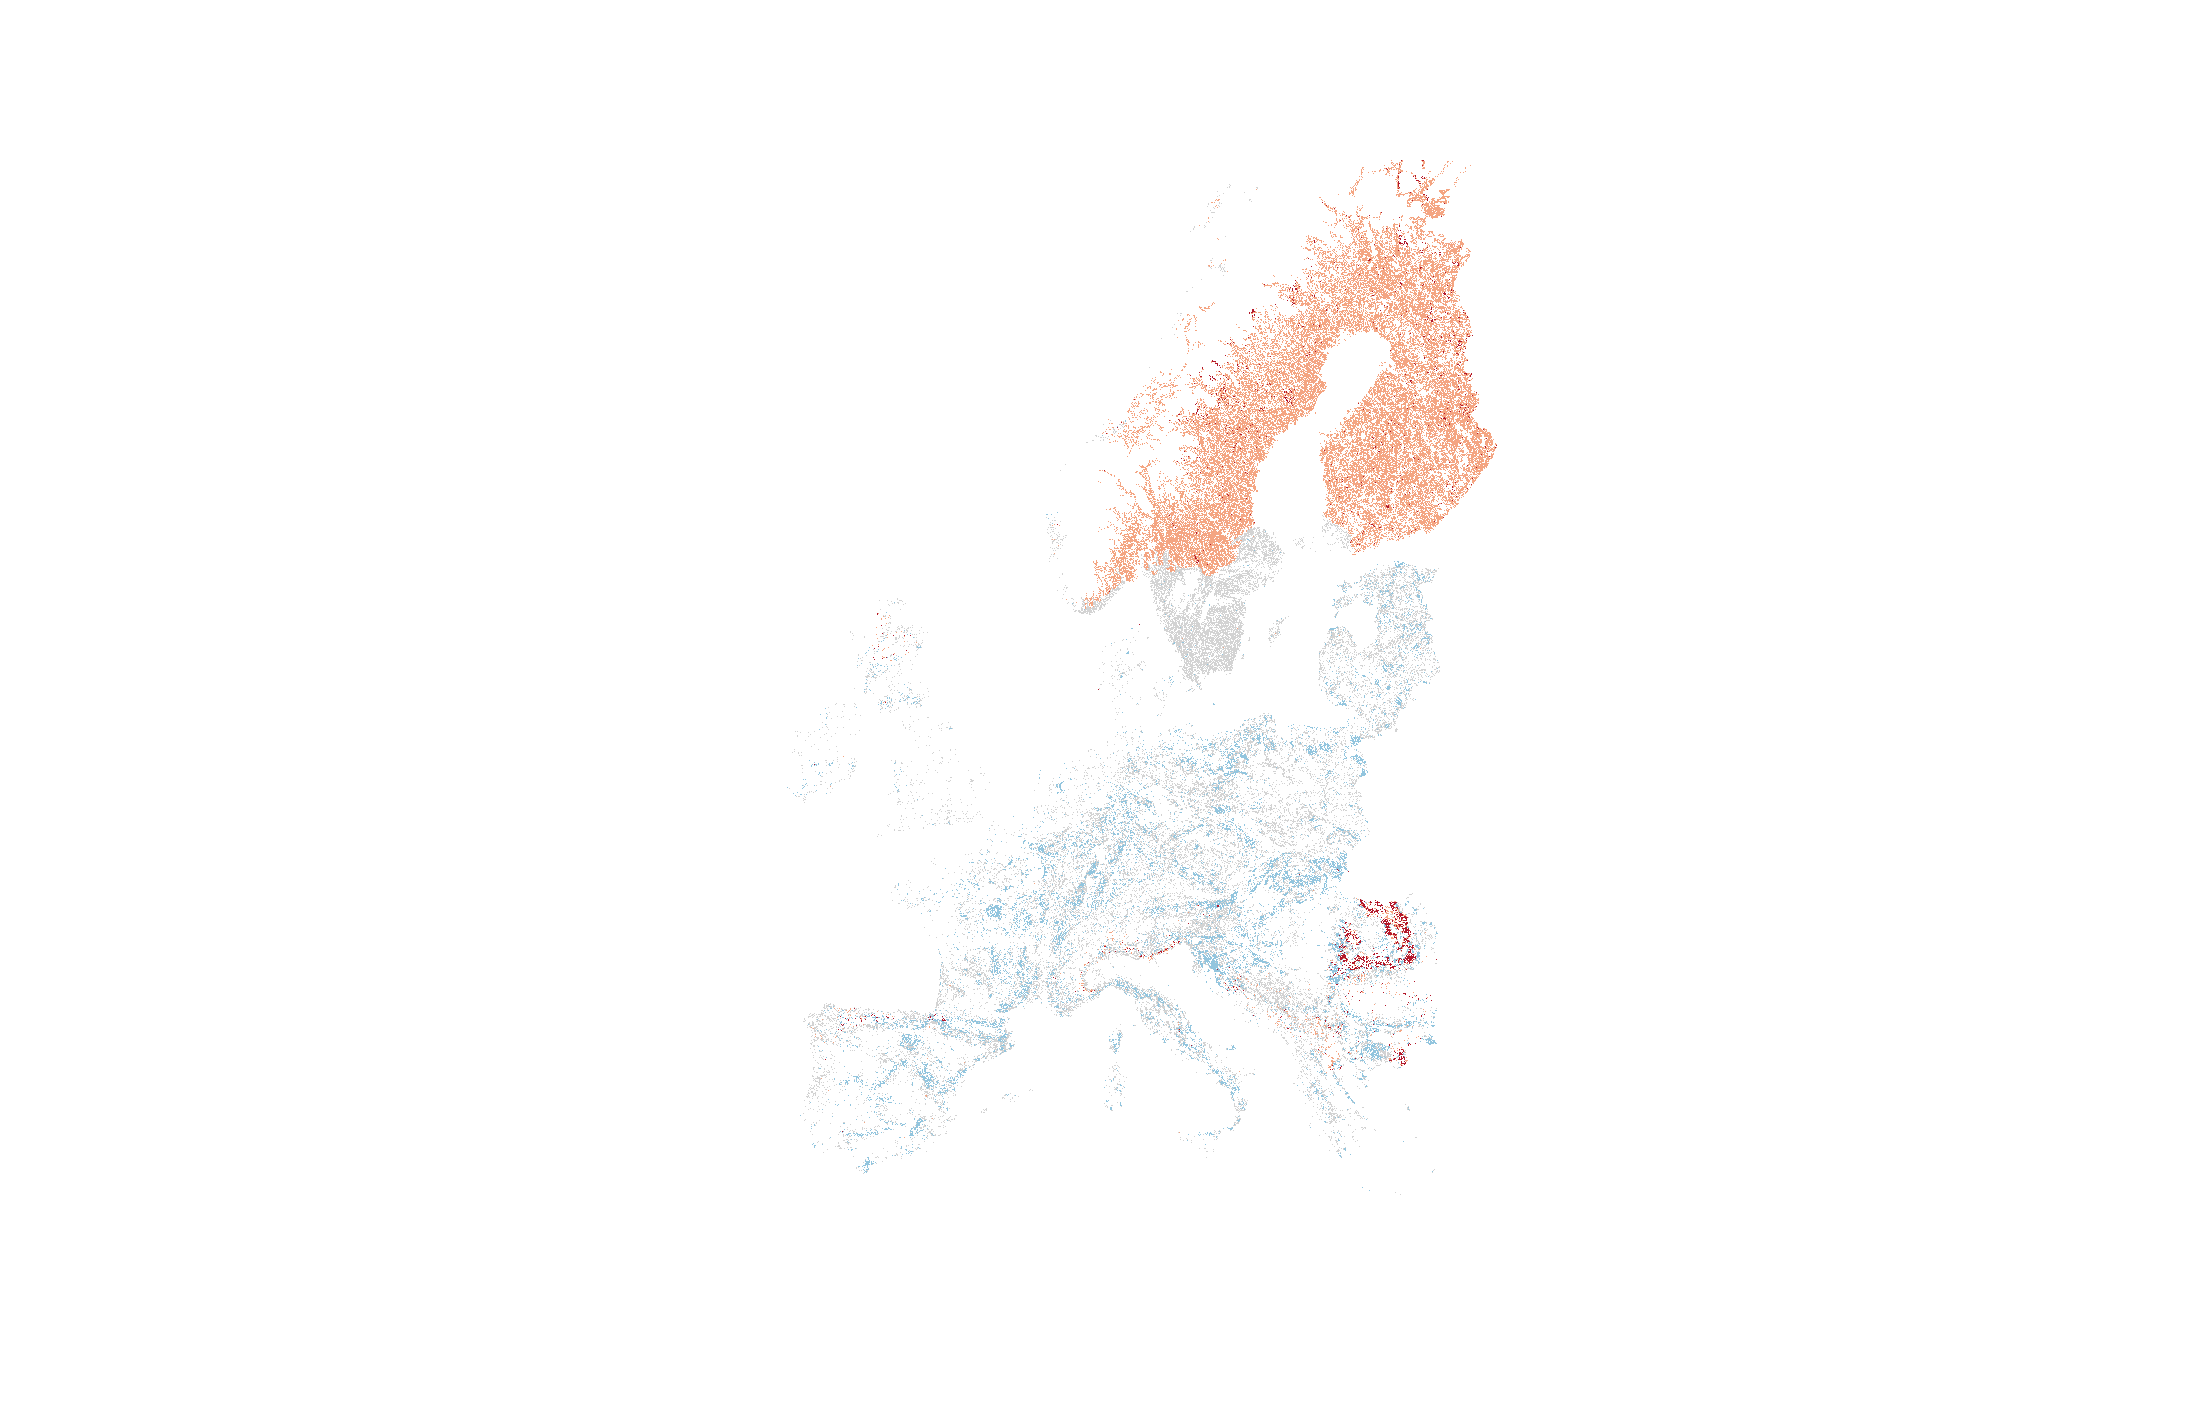
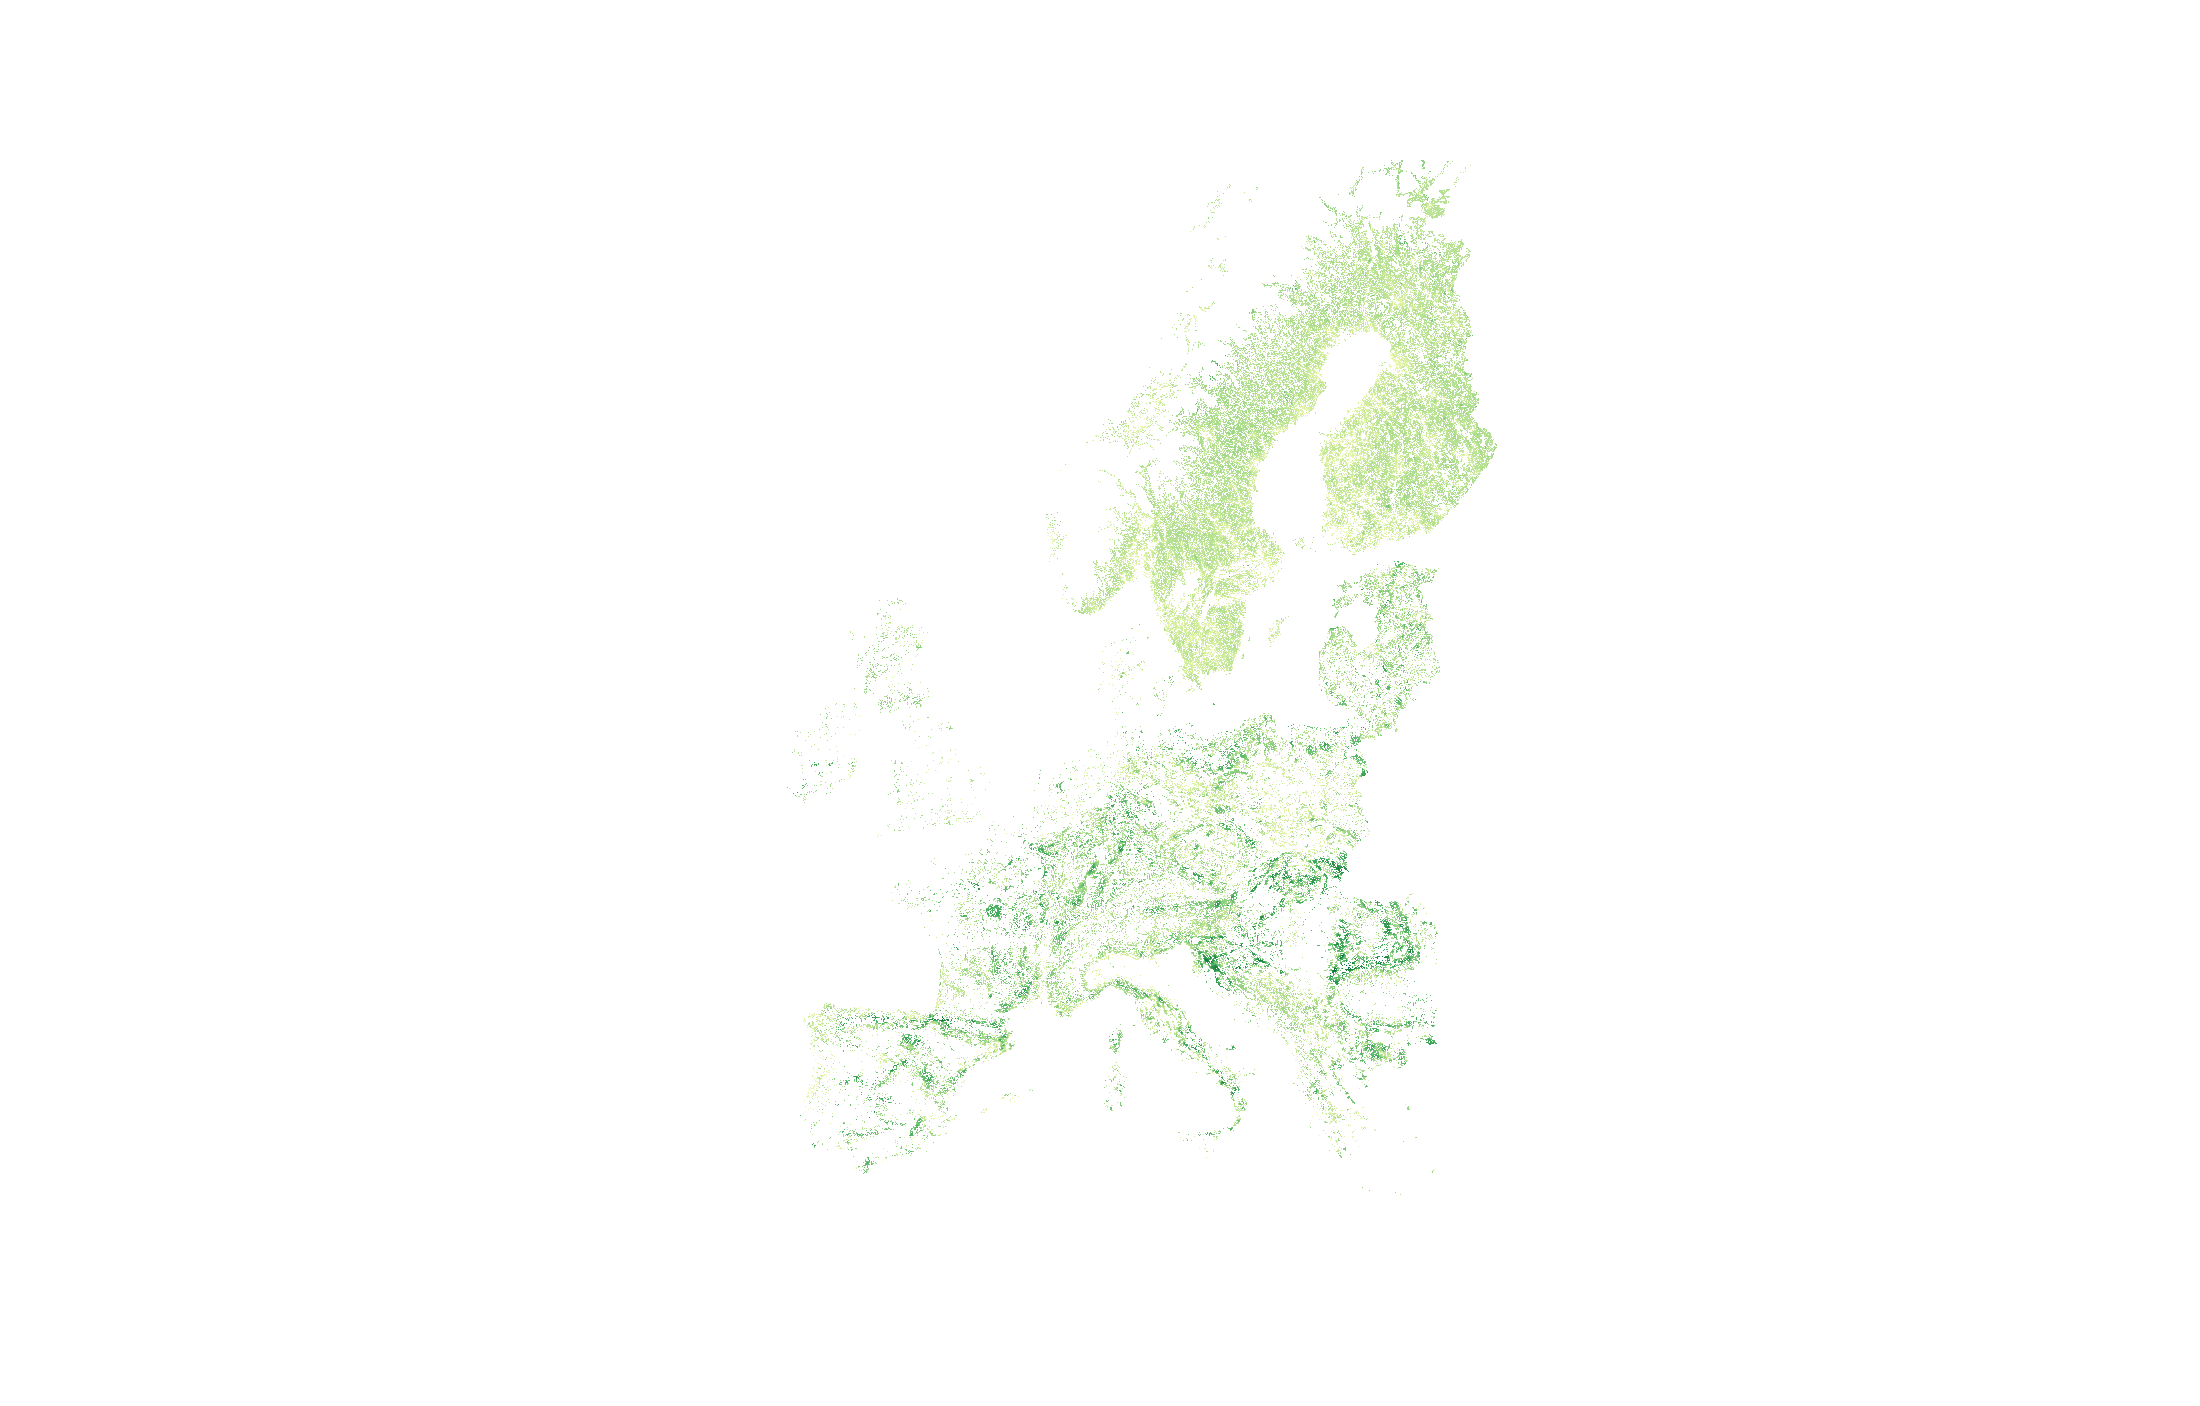
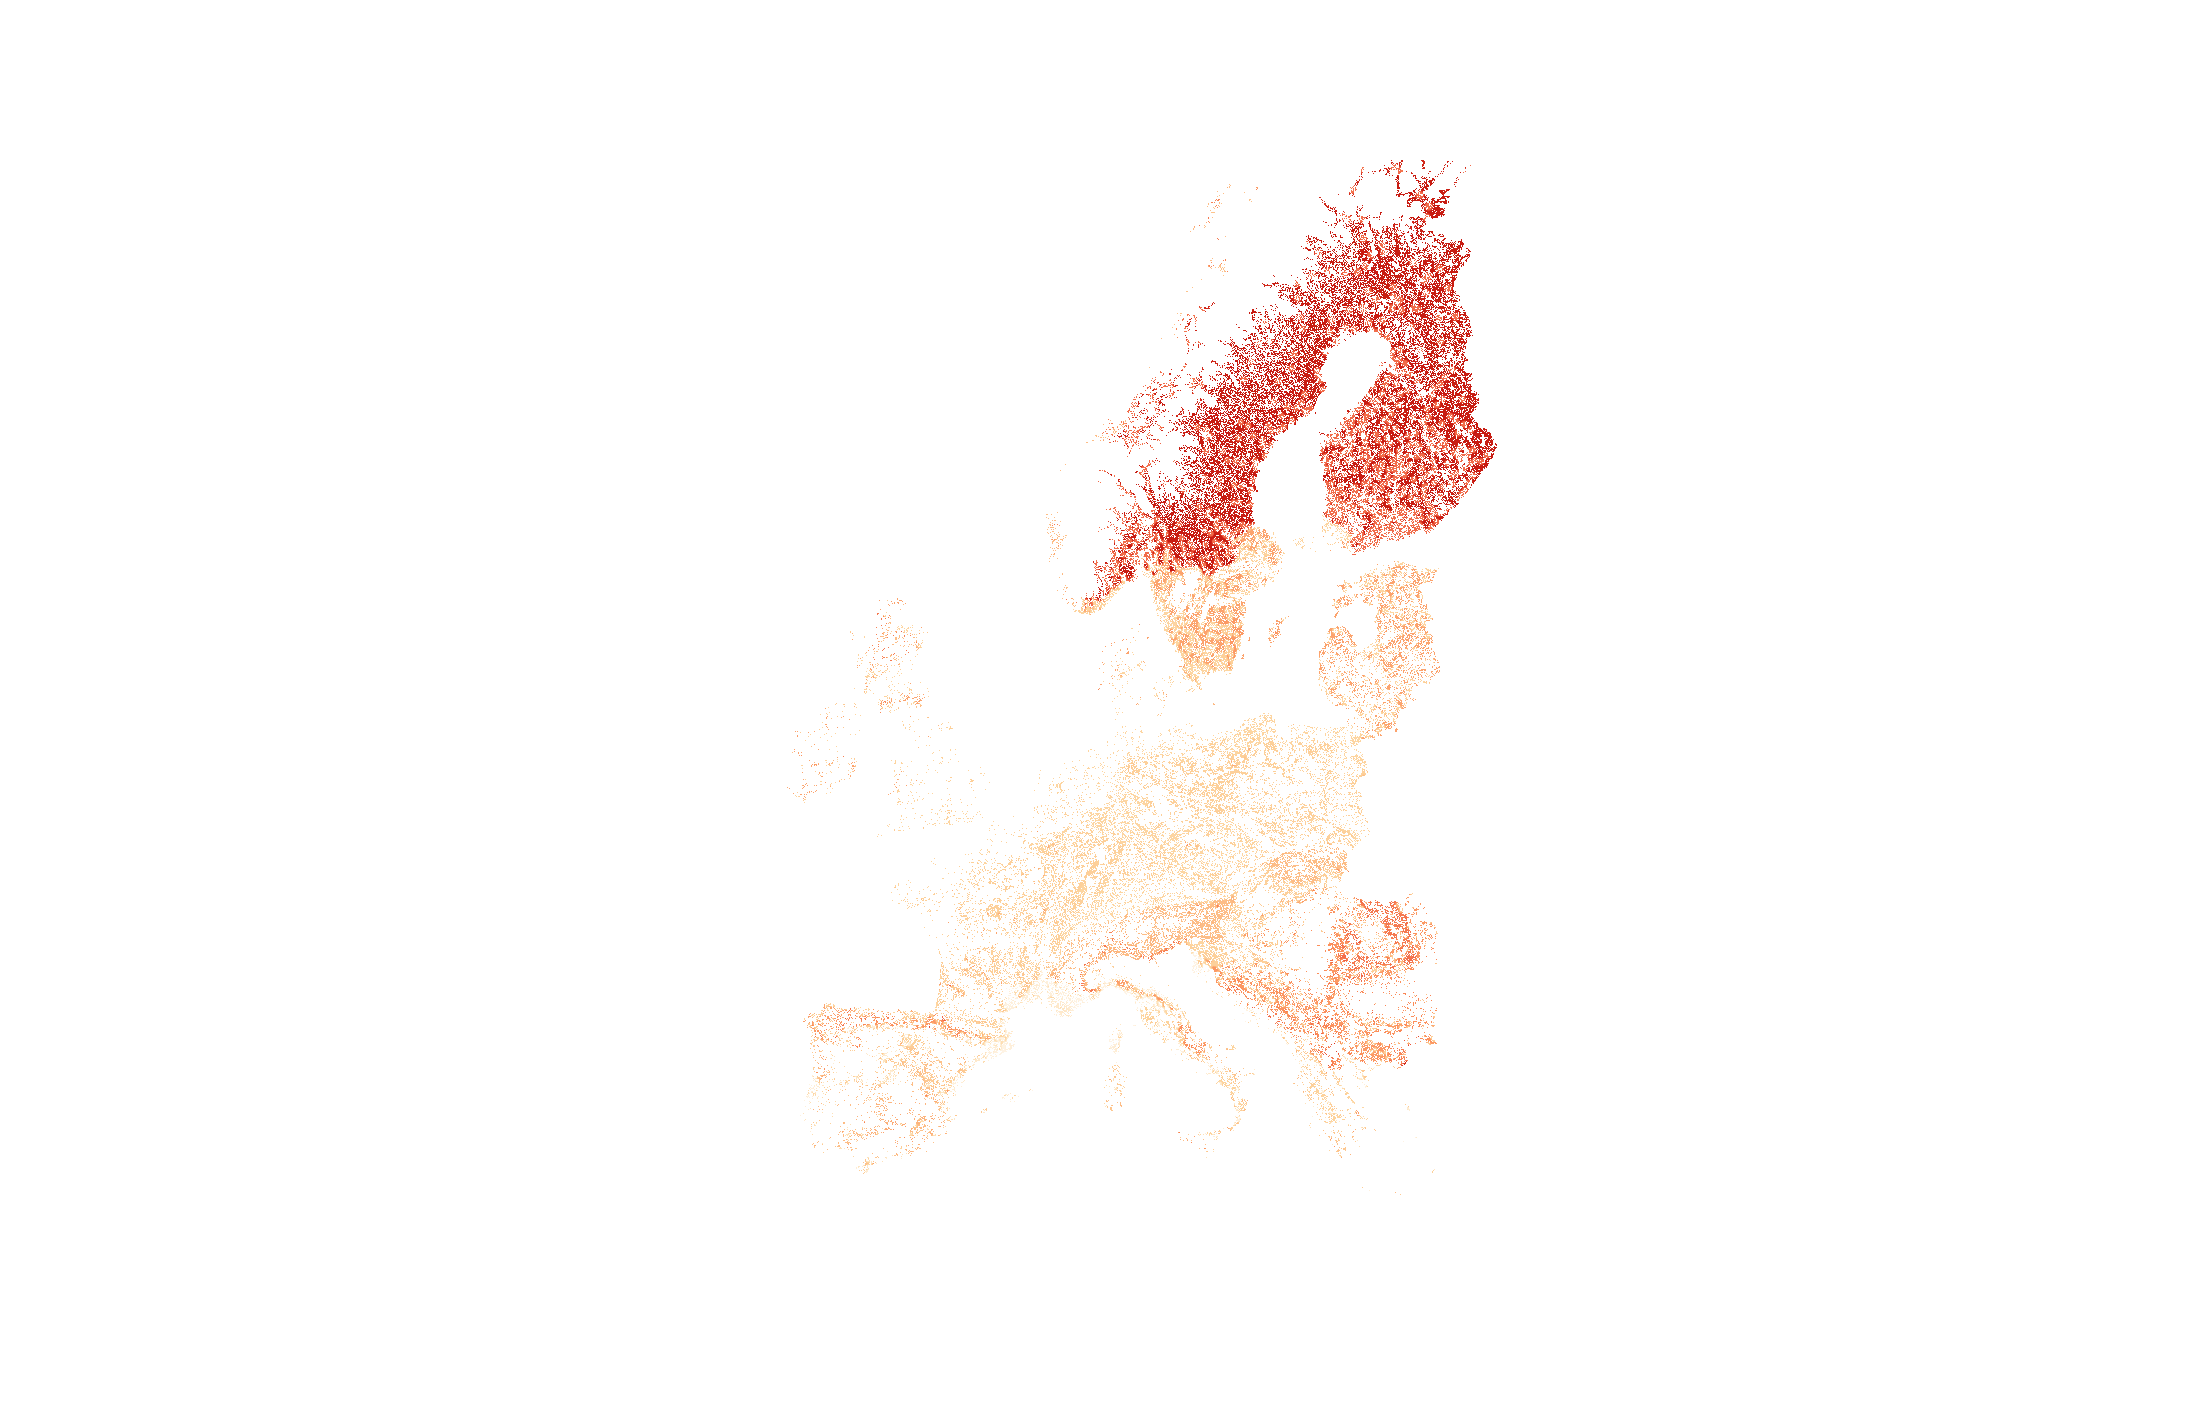

In [ ]:
html_path     = PATH_OUTPUTS / 'Wildfire_interactive_map.html'
max_dimension = 2200
leaflet_crs   = 'EPSG:3857'

if policy_gdf.crs != "EPSG:4326":
    policy_gdf = policy_gdf.to_crs(epsg=4326)

class BivariateMapLegend(MacroElement):
    def __init__(self, colors):
        super(BivariateMapLegend, self).__init__()
        self.colors = colors
        
    def render(self, **kwargs):
        html_content = f"""
        <div id="biv-legend" style="
            position: fixed; 
            bottom: 30px; left: 30px; width: 140px; height: 140px; 
            background-color: rgba(28, 28, 46, 0.9);
            border: 1px solid #ffffff;
            z-index:9999; font-size:11px; color: white;
            padding: 10px; border-radius: 6px;
            font-family: 'Helvetica Neue', Arial, sans-serif;
            box-shadow: 0 0 15px rgba(0,0,0,0.5);
            pointer-events: auto;
        ">
            <div style="text-align:center; font-weight:bold; margin-bottom:10px; letter-spacing: 0.5px;">Risk Matrix</div>
            <div style="position: relative; width: 120px; height: 80px;">
                
                <div style="position: absolute; top: 32px; left: -25px; transform: rotate(-90deg); font-size: 9px; font-weight: bold; width: 80px; text-align: center; color: #cccccc;">
                    Eco Value →
                </div>
                
                <div style="position: absolute; top: 75px; left: 20px; font-size: 9px; font-weight: bold; width: 80px; text-align: center; color: #cccccc;">
                    Vulnerability →
                </div>
                
                <div style="display: grid; grid-template-columns: 35px 35px; grid-template-rows: 35px 35px; gap: 0px; position: absolute; left: 25px; top: 0px;">
                    <div style="background-color: {self.colors[3]}; border-radius: 0px;"></div>
                    <div style="background-color: {self.colors[4]}; border-radius: 0px;"></div>
                    <div style="background-color: {self.colors[1]}; border-radius: 0px;"></div>
                    <div style="background-color: {self.colors[2]}; border-radius: 0px;"></div>
                </div>
                
                <div style="position: absolute; top: 16px; left: 15px; font-size: 9px; text-align: right; width: 25px; color: #aaaaaa;"/div>
                <div style="position: absolute; top: 54px; left: 15px; font-size: 9px; text-align: right; width: 25px; color: #aaaaaa;"/div>
                
                <div style="position: absolute; top: 82px; left: 45px; font-size: 9px; text-align: center; width: 35px; color: #aaaaaa;"/div>
                <div style="position: absolute; top: 82px; left: 83px; font-size: 9px; text-align: center; width: 35px; color: #aaaaaa;"/div>
            </div>
        </div>
        """
        from branca.element import Element
        # Einbindung in das Leaflet/Folium-Dokument via Script-Injektion
        # Verhindert Inkompatibilitäten zwischen Jinja2-Versionen
        script = f"""
        <script type="text/javascript">
            $(document).ready(function() {{
                $('body').append(`{html_content}`);
            }});
        </script>
        """
        
        # Fügt das Skript dem Header/Body der Folium-Karte hinzu
        fig = self.get_root()
        fig.html.add_child(Element(script), name="bivariate_legend_script")

def continuous_overlay(arr_3035, cmap_name, layer_name, opacity=0.75):
    """
    Reproject a 0-1 float32 array to web-mercator and return a Folium ImageOverlay.
    """
    mem = rasterio.io.MemoryFile()
    tmp_p = {**profile, 'nodata': np.nan}
    with mem.open(**tmp_p) as tmp:
        out = arr_3035.copy(); out[~np.isfinite(out)] = np.nan
        tmp.write(out, 1)
    with mem.open() as src:
        dt, dw, dh = calculate_default_transform(src.crs, leaflet_crs, src.width, src.height, *src.bounds)
        sc = max(dw, dh) / max_dimension
        dw_orig, dh_orig = dw, dh  
        if sc > 1:
            dw, dh = int(dw/sc), int(dh/sc)
            dt = dt * Affine.scale(dw_orig / dw, dh_orig / dh)
        wm = np.full((dh, dw), np.nan, dtype='float32')
        reproject(source=rasterio.band(src, 1), destination=wm,
                  src_transform=src.transform, src_crs=src.crs, src_nodata=np.nan,
                  dst_transform=dt, dst_crs=leaflet_crs, dst_nodata=np.nan,
                  resampling=Resampling.bilinear)
    wm_b, sm_m, em, nm = array_bounds(dh, dw, dt)
    w, s, e, n = transform_bounds(leaflet_crs, 'EPSG:4326', wm_b, sm_m, em, nm, densify_pts=21)
    msk = np.isfinite(wm)
    cmap = plt.get_cmap(cmap_name)
    rgba = np.zeros((dh, dw, 4), dtype=np.uint8)
    rgba[msk] = (cmap(np.clip(wm[msk], 0, 1)) * 255).astype(np.uint8)
    png = BytesIO(); Image.fromarray(rgba).save(png, format='PNG')
    url = 'data:image/png;base64,' + base64.b64encode(png.getvalue()).decode()
    return folium.raster_layers.ImageOverlay(image=url, bounds=[[s, w], [n, e]],
                                             opacity=opacity, name=layer_name, interactive=True), s, w, n, e

def bivariate_overlay(biv_arr, colors, layer_name, opacity=0.85):
    """
    Render the categorical bivariate array as an RGBA PNG overlay.
    """
    # Nearest-neighbour reproject the integer classes
    mem = rasterio.io.MemoryFile()
    tmp_p = {**profile, 'nodata': 0, 'dtype': 'float32'}
    with mem.open(**tmp_p) as tmp:
        out = biv_arr.copy(); out[~np.isfinite(out)] = 0
        tmp.write(out, 1)
    with mem.open() as src:
        dt, dw, dh = calculate_default_transform(src.crs, leaflet_crs, src.width, src.height, *src.bounds)
        sc = max(dw, dh) / max_dimension
        dw_orig, dh_orig = dw, dh 
        if sc > 1:
            dw, dh = int(dw/sc), int(dh/sc)
            dt = dt * Affine.scale(dw_orig / dw, dh_orig / dh)
        wm = np.full((dh, dw), np.nan, dtype='float32')
        reproject(source=rasterio.band(src, 1), destination=wm,
                  src_transform=src.transform, src_crs=src.crs, src_nodata=0,
                  dst_transform=dt, dst_crs=leaflet_crs, dst_nodata=np.nan,
                  resampling=Resampling.nearest)
    wm_b, sm_m, em, nm = array_bounds(dh, dw, dt)
    w, s, e, n = transform_bounds(leaflet_crs, 'EPSG:4326', wm_b, sm_m, em, nm, densify_pts=21)
    
    rgba = np.zeros((dh, dw, 4), dtype=np.uint8)
    
    valid_mask = np.isfinite(wm)
    wm_int = np.zeros_like(wm, dtype=int)
    wm_int[valid_mask] = np.rint(wm[valid_mask]).astype(int)
    
    for cls, hex_col in colors.items():
        r, g, b, _ = [int(v*255) for v in mcolors.to_rgba(hex_col)]
        rgba[valid_mask & (wm_int == cls)] = [r, g, b, 255]
        
    png = BytesIO(); Image.fromarray(rgba).save(png, format='PNG')
    url = 'data:image/png;base64,' + base64.b64encode(png.getvalue()).decode()
    return folium.raster_layers.ImageOverlay(image=url, bounds=[[s, w], [n, e]],
                                             opacity=opacity, name=layer_name, interactive=True), s, w, n, e

# Build overlays
biv_layer,  south, west, north, east = bivariate_overlay(bivariate, BIV_COLORS, 'Bivariate Risk Matrix')
mesli_layer, *_  = continuous_overlay(mesli_arr, 'YlGn', 'MESLI – Ecological Value (0-1)')
vuln_layer,  *_  = continuous_overlay(vuln_norm, 'OrRd',  'Vulnerability (0-1)')

m = folium.Map(location=[(south+north)/2, (west+east)/2], zoom_start=12, tiles=None)

folium.TileLayer('CartoDB Darkmatter', name='Basemap: CartoDB (Dark)', show=True).add_to(m)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri World Imagery', name='Basemap: Satelite', show=False
).add_to(m)

STYLE = {'fillOpacity': 0.6, 'color': 'black', 'weight': 1.0}

policy_gdf.explore(
    m=m, column='Yes_Count', cmap='Blues',
    name='Number of wildfire actions\nin national policies', show=False, legend=False,
    tooltip=['Country', 'Yes_Count', 'Group'],
    tooltip_kwds={'aliases': ['Country', 'Action-Count', 'Action-Class'], 'localize': True},
    missing_kwds={"color": "lightgrey"},
    style_kwds=STYLE
)

biv_layer.add_to(m)
mesli_layer.add_to(m)
vuln_layer.add_to(m)

m.add_child(BivariateMapLegend(BIV_COLORS))

folium.LayerControl().add_to(m)
m.fit_bounds([[south, west], [north, east]])
m.save(html_path)
print(f'Saved to {html_path}')

fig_map = folium.Figure(width='100%', height=750)
fig_map.add_child(m)
fig_map